<a href="https://colab.research.google.com/github/nicohervas/Procesos-Estocasticos/blob/main/Simulacion_GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
vector_medias = np.array([0,0,0])
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[  0.5109383    0.7259896   -4.79928575]
 [ -0.76393909   3.11822696  -8.01268963]
 [ -0.80180342   0.10884355  -4.35748694]
 [  0.58960489  -4.86045217   8.9449741 ]
 [  0.27803113  -1.53876591 -11.06416502]
 [  1.68940164  -2.67412132   7.01888512]
 [ -0.24821057   3.04690515   4.90507684]
 [  2.04637825  -7.47250314   9.63625758]
 [  0.48958194   7.48058959   4.15547943]
 [ -0.14336715   1.86992482   4.02862773]
 [  0.3729948    4.63453205  -2.73436773]
 [ -0.71667732  -2.059055     2.29113727]
 [ -1.40171831   2.65021892   4.06792109]
 [ -0.36847686   0.78954037  -6.96559487]
 [  1.11797775  -2.82541532 -23.44663577]
 [ -0.14197292   5.1577135   -2.3770743 ]
 [  0.40121627   9.33168629  -6.00559712]
 [  0.80280467  -2.24353562   6.29722843]
 [ -0.08297293   1.60741611   6.32784233]
 [  0.94521409  -1.81083617   5.41796045]
 [  0.80105277   1.96902632   7.0221351 ]
 [  1.09342522   3.07707823  -0.16852089]
 [ -1.14676084   1.83892884   0.66463486]
 [  1.0

In [3]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.
  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.
  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).
  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
  vector_medias = np.zeros_like(t)
  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.
  #El profesor recomienda como primer paso crear una matriz de distancias y construir la de covarianzas usando esta elemento a elemento.
  #Hay que hacerlo utilizando las propiedades de numpy, como el broadcasting.
  #Hacer un reshape de t a (1,n), otro a (n,1) y restarlo, así puede hacerse elemento a elemento.
  t_1 = t[:,np.newaxis]
  t_2 = t[np.newaxis,:]
  matriz_distancias = np.abs(t_1-t_2)
  matriz_covs = sigma_sq**2*np.exp(-0.5*(matriz_distancias/lengthscale)**2)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

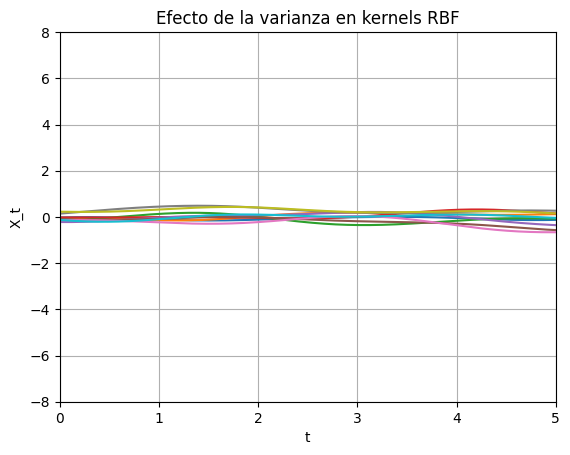

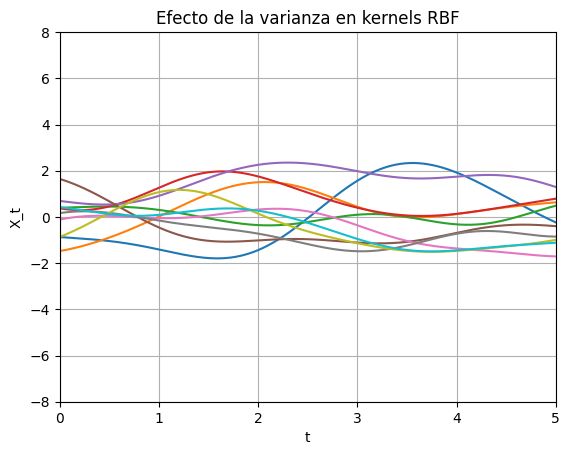

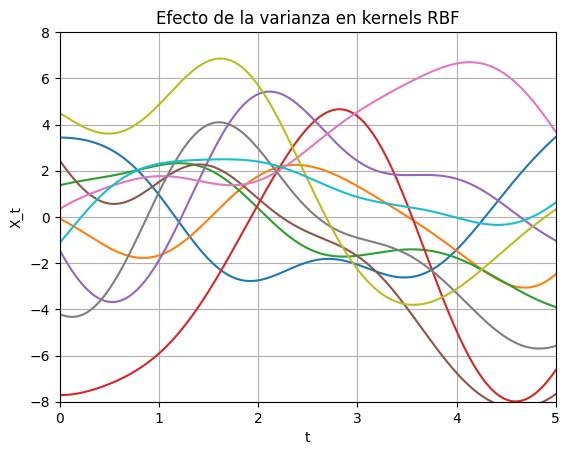

In [4]:
t = np.linspace(0,5,1000)
for i in [0.25, 1, 4]:
  samples=simular_GP_RBF(t, sigma_sq=i, lengthscale=1, num_samples=10)
  plt.ylim(-8, 8)
  plt.xlim(0,5)
  plt.title("Efecto de la varianza en kernels RBF")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()


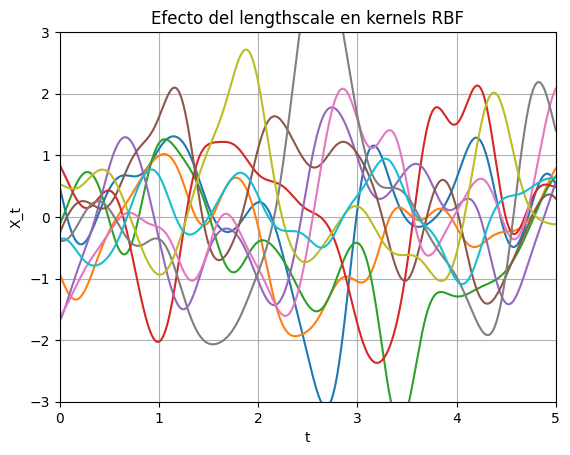

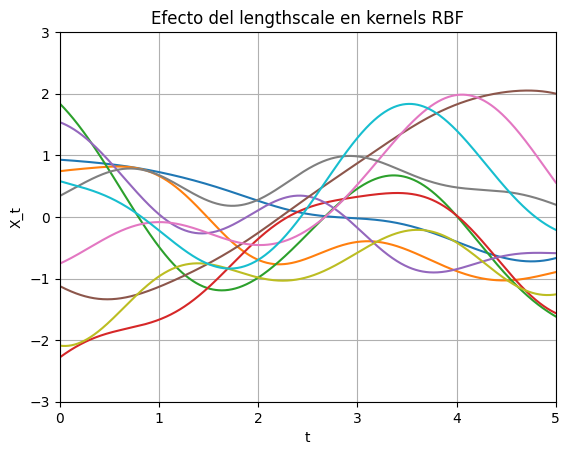

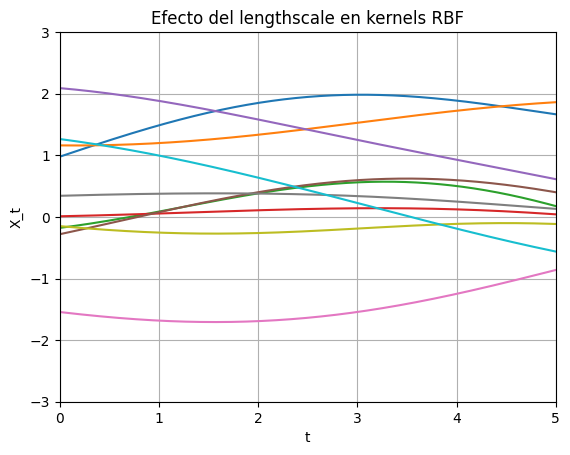

In [5]:
t = np.linspace(0,5,1000)
for i in [0.25, 1, 4]:
  samples=simular_GP_RBF(t, sigma_sq=1, lengthscale=i, num_samples=10)
  plt.ylim(-3, 3)
  plt.xlim(0,5)
  plt.title("Efecto del lengthscale en kernels RBF")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()


In [6]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=1, num_samples=1):
  #Queremos la función de medias constantemente 0
  vector_medias=np.zeros_like(t)
  #Sacamos la matriz de covarianzas
  t_1 = t[:,np.newaxis]
  t_2 = t[np.newaxis,:]
  matriz_distancias = np.abs(t_1-t_2)
  matriz_covs=sigma_sq**2*np.exp(-2/lengthscale**2*np.sin(np.pi*matriz_distancias/periodo)**2)
  #Conseguimos las realizaciones del proceso
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

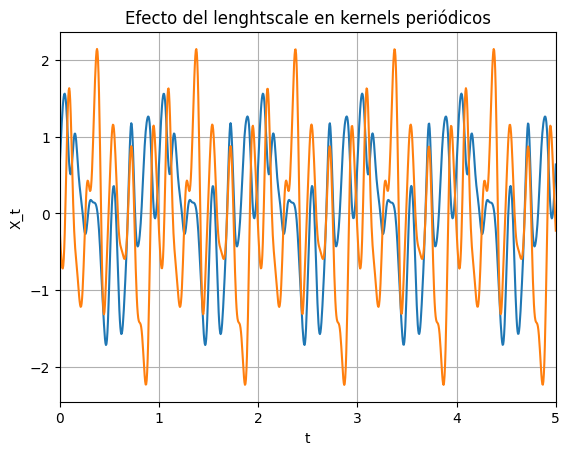

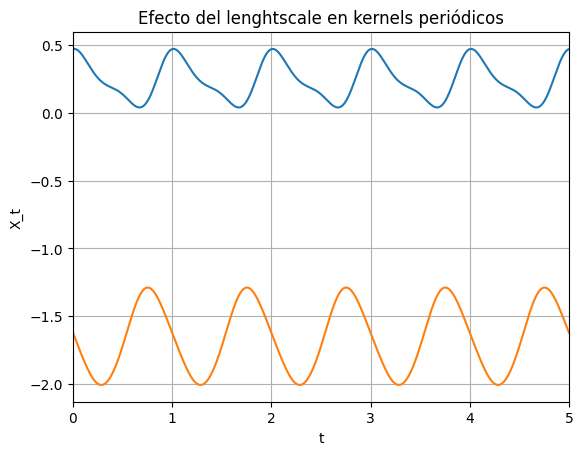

In [7]:
t = np.linspace(0,5,1000)
for i in [0.25, 4]:
  samples=simular_GP_periodic(t, sigma_sq=1, lengthscale=i, periodo=1, num_samples=2)
  #plt.ylim(-2, 2)
  plt.xlim(0,5)
  plt.title("Efecto del lenghtscale en kernels periódicos")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()

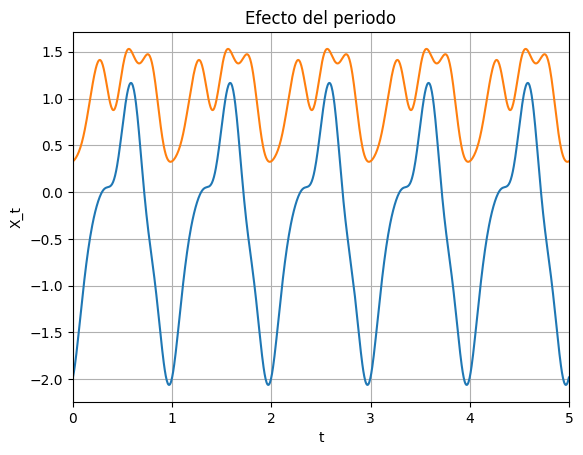

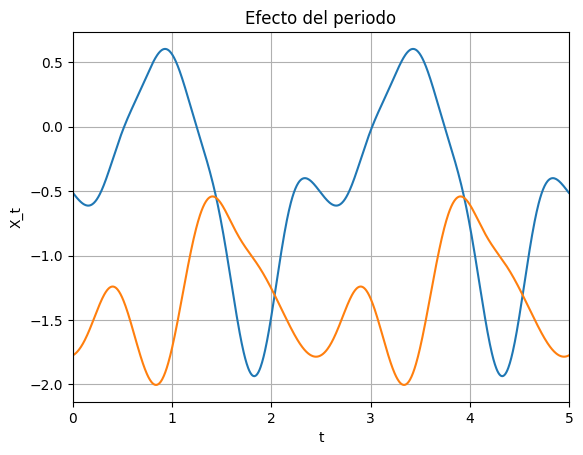

In [8]:
t = np.linspace(0,5,1000)
for i in [1, 2.5]:
  samples=simular_GP_periodic(t, sigma_sq=1, lengthscale=1, periodo=i, num_samples=2)
  #plt.ylim(-2.5, 2.5)
  plt.xlim(0,5)
  plt.title("Efecto del periodo")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()

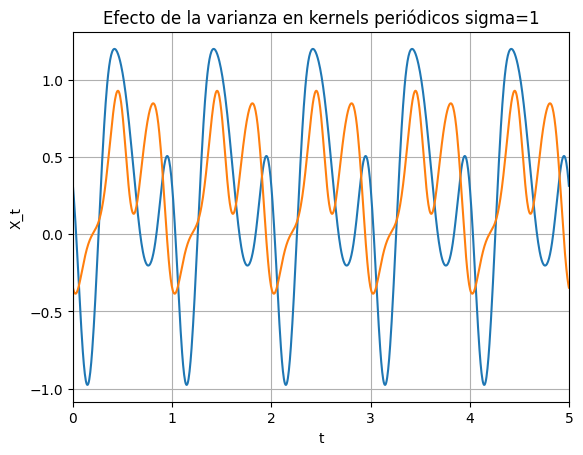

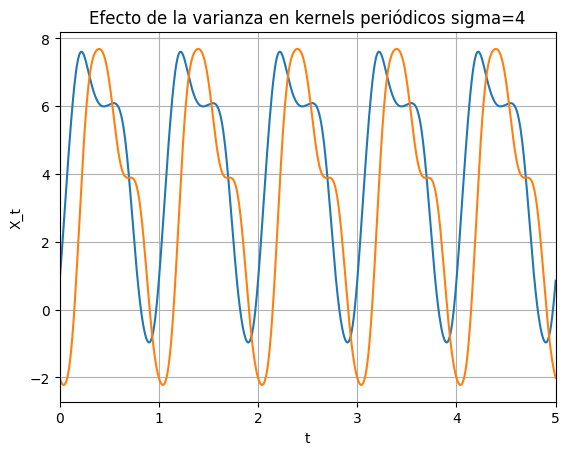

In [19]:
t = np.linspace(0,5,1000)
for i in [1, 4]:
  samples=simular_GP_periodic(t, sigma_sq=i, lengthscale=1, periodo=1, num_samples=2)
  #plt.ylim(-2.5, 2.5)
  plt.xlim(0,5)
  plt.title(f"Efecto de la varianza en kernels periódicos sigma={i}")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()

In [14]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo de los monomios utilizados. Int.
    num_samples: número de muestras a generar. Int.
    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    # Paso 1: calcula el vector de medias.
    vector_medias = np.zeros_like(t)
    # Paso 2: calcula la matriz de covarianzas.
    # [OPCIÓN 2: Usando el producto matricial F*F^T visto en la diapositiva 82]
    n = len(t)
    # Crear matriz de exponentes
    potencias = np.arange(m+1)                    # [0, 1, 2, ..., m]
    # Elevar cada t[i] a cada potencia k con broadcasting
    F = t[:, np.newaxis] ** potencias             # Shape: (n, m)
    # Multiplicación matricial
    matriz_covs = F @ F.T                         # Shape: (n, n)
    # En cualquiera de las OPCIONES anteriores, la matriz de covarianzas resultante podría no ser semidefinida positiva (por problemas numéricos de redondeo).
    # Para resolverlo, es muy habitual y recomendable sumar un "jitter" o ruido definido positivo, es decir, sumar por ejemplo la identidad multplicada por un valor pequeño:
    matriz_covs = matriz_covs + 1e-9 * np.eye(n)

    # Paso 3: obtén las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)

    return samples

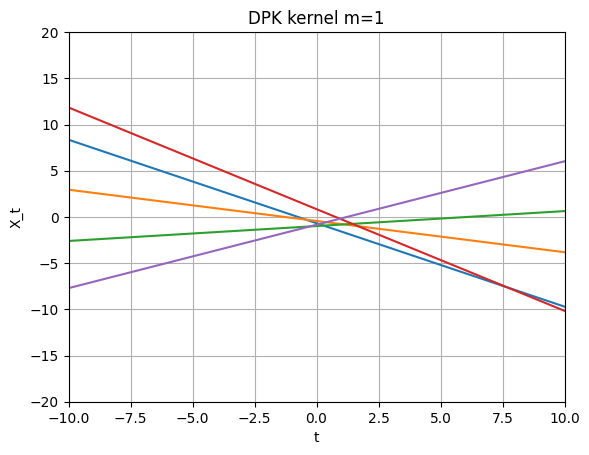

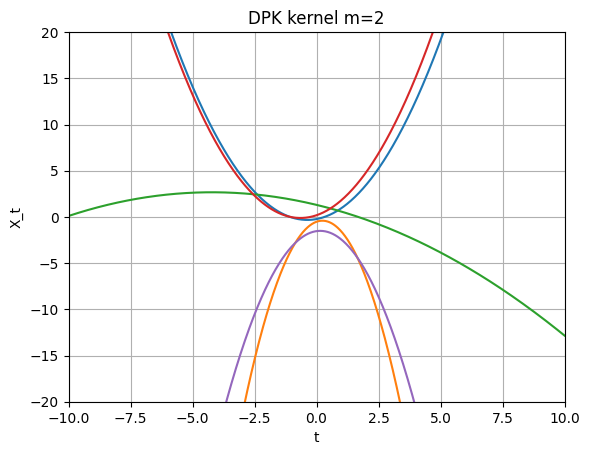

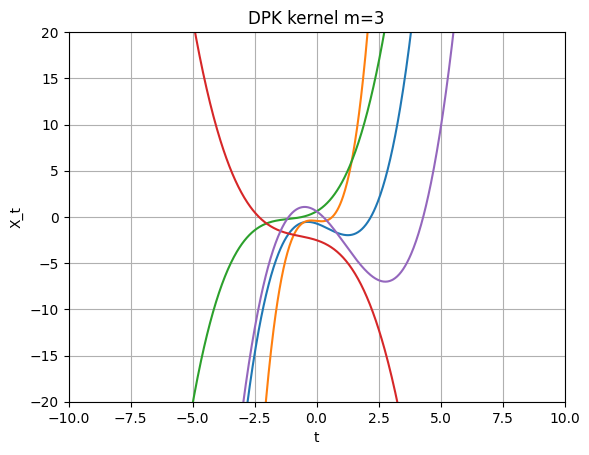

In [17]:
t = np.linspace(-10,10,1000)
for i in [1,2,3]:
  samples=simular_GP_DPKpoly(t, m=i, num_samples=5)
  plt.ylim(-20,20)
  plt.xlim(-10,10)
  plt.title(f"DPK kernel m={i}")
  plt.xlabel("t")
  plt.ylabel("X_t")
  plt.grid()
  plt.plot(t, samples.T)
  plt.show()